# Data Collection

Clean pipeline: configuration first, Bloomberg files loaded, cleaned, checked, and saved for the model notebook.

In [41]:
# 0 — CONFIGURATION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import json
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# directory path
DATA_DIR = Path('/Users/sca/Desktop/MS203/Masters Thesis/Script /data')

BLOOMBERG_FILES = {
    'bloom_midjun2026.xlsx': '~1M',
    'bloom_midsep2026.xlsx': '~3M',
    'bloom_middec2026.xlsx': '~6M',
    'bloom_midjun2027.xlsx': '~1Y',
    'bloom_middec2031.xlsx': '~5Y',
}

# Spot from Bloomberg collection date — kept fixed for consistency with option chain
S0 = 7383.74
SPOT_DATE = '2026-06-08'

# Cleaning filters
MONEYNESS_MIN = 0.50
MONEYNESS_MAX = 1.50
MIN_OINT = 75

OPTIONS_OUT = DATA_DIR / 'spx_options_bloom.csv'
SPOT_OUT = DATA_DIR / 'spx_spot_history.csv'
META_OUT = DATA_DIR / 'metadata_bloom.json'

print(f'Data directory : {DATA_DIR}')
print(f'Spot price     : {S0:.2f} ({SPOT_DATE})')
print(f'Files to load  : {len(BLOOMBERG_FILES)}')

Data directory : /Users/sca/Desktop/MS203/Masters Thesis/Script /data
Spot price     : 7383.74 (2026-06-08)
Files to load  : 5


## 1 — Spot history 

In [42]:
# 1 — SPOT HISTORY

# This section uses yfinance only for historical realised returns.
# It does NOT overwrite the Bloomberg spot S0 used for option pricing.

try:
    import yfinance as yf

    spx_history = yf.download('^SPX', start='2005-01-01', end=SPOT_DATE, progress=False)
    spx_history = spx_history[['Close']].copy()
    spx_history.columns = ['Close']
    spx_history.index.name = 'Date'
    spx_history = spx_history.dropna()
    spx_history.to_csv(SPOT_OUT)

    print(f'Spot history saved: {len(spx_history)} trading days')
    print(f'From: {spx_history.index[0].date()}')
    print(f'To  : {spx_history.index[-1].date()}')
    print(spx_history.tail(3))
except Exception as e:
    print(f'Spot history download skipped: {e}')
    print('You can still run the options collection. Realised VaR will be skipped later if spot history is missing.')

Spot history saved: 5390 trading days
From: 2005-01-03
To  : 2026-06-05
                  Close
Date                   
2026-06-03  7553.680176
2026-06-04  7584.310059
2026-06-05  7383.740234


## 2 — Bloomberg loader

As data was collected from Bloomberg OMON excels, we needed to load it in a correct format

In [43]:

# 2 — BLOOMBERG LOADER FUNCTION

def load_bloomberg_file(filepath):
    """
    Loads one Bloomberg OMON Excel export.
    Expected structure:
      Row 0 : Calls / Puts section headers
      Row 1 : column names
      Row 2 : maturity/rate info string
      Row 3+: option data
    """
    df_raw = pd.read_excel(filepath, engine='openpyxl', header=None)

    maturity_info = str(df_raw.iloc[2, 0])

    date_match = re.search(r'(\d{1,2}-\w{3}-\d{2,4})', maturity_info)
    maturity_date = date_match.group(1) if date_match else 'Unknown'

    r_match = re.search(r'R\s+([\d.]+)', maturity_info)
    r = float(r_match.group(1)) / 100 if r_match else np.nan

    col_names = ['Ticker', 'Strike', 'Bid', 'Ask', 'Last',
                 'IVM', 'Volm', 'OInt', 'DM', 'TM', 'GM', 'VM']
    n_cols = len(col_names)

    df_data = df_raw.iloc[3:].copy().reset_index(drop=True)

    calls = df_data.iloc[:, :n_cols].copy()
    puts = df_data.iloc[:, n_cols:n_cols*2].copy()
    calls.columns = col_names
    puts.columns = col_names

    calls['type'] = 'call'
    puts['type'] = 'put'

    options = pd.concat([calls, puts], ignore_index=True)
    options['maturity'] = maturity_date
    options['r'] = r

    return options, maturity_date, r

## 3 — Load all Bloomberg files

In [44]:
# 3 — LOAD ALL FILES

all_options = []

print(f"{'File':<30} {'Maturity':<15} {'R':>8} {'Raw rows':>10}")
print('-' * 70)

for filename, label in BLOOMBERG_FILES.items():
    filepath = DATA_DIR / filename
    try:
        df, maturity, r = load_bloomberg_file(filepath)
        df['label'] = label
        all_options.append(df)
        print(f"{filename:<30} {maturity:<15} {r:>8.2%} {len(df):>10}")
    except Exception as e:
        print(f"{filename:<30} ERROR: {e}")

if not all_options:
    raise RuntimeError('No Bloomberg files were loaded. Check DATA_DIR and file names.')

options_raw = pd.concat(all_options, ignore_index=True)
print(f'\nTotal raw options: {len(options_raw):,}')

File                           Maturity               R   Raw rows
----------------------------------------------------------------------
bloom_midjun2026.xlsx          18-Jun-26          3.94%       1000
bloom_midsep2026.xlsx          18-Sep-26          3.95%        992
bloom_middec2026.xlsx          18-Dec-26          4.04%        464
bloom_midjun2027.xlsx          17-Jun-27          4.18%        476
bloom_middec2031.xlsx          19-Dec-31          4.27%       1070

Total raw options: 4,002


## 4 — Clean and filter options

In [45]:
# 4 — CLEAN AND FILTER

def clean_options(df, S0, moneyness_min=0.50, moneyness_max=1.50, min_oint=75):
    df = df.copy()

    numeric_cols = ['Strike', 'Bid', 'Ask', 'Last', 'IVM', 'Volm', 'OInt', 'DM', 'GM', 'VM', 'TM']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df['mid'] = (df['Bid'] + df['Ask']) / 2
    df['moneyness'] = df['Strike'] / S0

    df = df[df['Bid'].notna() & (df['Bid'] > 0)]
    df = df[df['Ask'].notna() & (df['Ask'] > 0)]
    df = df[df['mid'].notna() & (df['mid'] > 0)]
    df = df[df['moneyness'].between(moneyness_min, moneyness_max)]
    df = df[df['IVM'].notna() & (df['IVM'] > 0)]
    df = df[df['OInt'].fillna(0) >= min_oint]

    return df.reset_index(drop=True)

options_clean = clean_options(
    options_raw,
    S0=S0,
    moneyness_min=MONEYNESS_MIN,
    moneyness_max=MONEYNESS_MAX,
    min_oint=MIN_OINT,
)

print(f'Raw   : {len(options_raw):,} options')
print(f'Clean : {len(options_clean):,} options')
display(options_clean.groupby(['maturity', 'type'])['Strike'].count().unstack())

Raw   : 4,002 options
Clean : 2,546 options


type,call,put
maturity,,
17-Jun-27,98,165
18-Dec-26,158,170
18-Jun-26,363,373
18-Sep-26,170,292
19-Dec-31,365,392


## 5 — Final dataset for models

In [46]:
# 5 — ADD TIME TO MATURITY AND SAVE MODEL DATASET

def parse_maturity_date(maturity_str):
    for fmt in ['%d-%b-%Y', '%d-%b-%y']:
        try:
            return pd.to_datetime(maturity_str, format=fmt)
        except Exception:
            pass
    return pd.NaT

today = pd.Timestamp(SPOT_DATE)

options_clean['maturity_dt'] = options_clean['maturity'].apply(parse_maturity_date)
options_clean['T'] = (options_clean['maturity_dt'] - today).dt.days / 365.25
options_clean['S0'] = S0

options_final = options_clean.rename(columns={
    'Strike': 'strike',
    'Bid': 'bid',
    'Ask': 'ask',
    'IVM': 'impliedVolatility',
    'OInt': 'openInterest',
    'DM': 'delta',
    'GM': 'gamma',
    'VM': 'vega',
    'TM': 'theta',
})

# Bloomberg IVM is in percent
options_final['impliedVolatility'] = options_final['impliedVolatility'] / 100
options_final['type'] = options_final['type'].str.lower().str.strip()

keep_cols = [
    'type', 'maturity', 'T', 'strike', 'mid', 'bid', 'ask',
    'impliedVolatility', 'moneyness', 'openInterest',
    'delta', 'gamma', 'vega', 'theta', 'r', 'S0', 'label'
]
options_final = options_final[keep_cols].dropna(subset=['T', 'strike', 'mid', 'r', 'S0']).copy()
options_final = options_final[options_final['T'] > 0].reset_index(drop=True)

print(f'Final dataset: {len(options_final):,} options')
print(f'T range      : {options_final["T"].min():.3f}Y to {options_final["T"].max():.3f}Y')
print(f'Strike range : {options_final["strike"].min():.0f} to {options_final["strike"].max():.0f}')
display(options_final.head())

Final dataset: 2,546 options
T range      : 0.027Y to 5.530Y
Strike range : 3700 to 11000


,type,maturity,T,strike,mid,bid,ask,impliedVolatility,moneyness,openInterest,delta,gamma,vega,theta,r,S0,label
0,call,18-Jun-26,0.027379,5750.0,1697.849854,1692.099854,1703.599854,0.489955,0.778738,1212.0,0.998806,0.000517,0.060601,-0.253156,0.0394,7383.74,~1M
1,call,18-Jun-26,0.027379,5800.0,1648.050049,1642.300049,1653.800049,0.494897,0.785510,4844.0,0.998109,0.000742,0.087796,-0.300887,0.0394,7383.74,~1M
2,call,18-Jun-26,0.027379,5850.0,1598.250000,1592.500000,1604.000000,0.513044,0.792281,1056.0,0.996438,0.001217,0.149342,-0.424373,0.0394,7383.74,~1M
3,call,18-Jun-26,0.027379,5875.0,1573.349854,1567.599854,1579.099854,0.509539,0.795667,1285.0,0.996101,0.001324,0.161281,-0.444026,0.0394,7383.74,~1M
4,call,18-Jun-26,0.027379,5900.0,1548.449951,1542.699951,1554.199951,0.489790,0.799053,6274.0,0.996720,0.001189,0.139231,-0.387726,0.0394,7383.74,~1M


## 6 — Descriptive checks and smile plot

n  strike_min  strike_max  iv_min  iv_max   oi_total
label maturity  type                                                        
~1M   18-Jun-26 call  363      5750.0      8325.0  0.1273  0.5130  2289562.0
                put   373      5740.0     11000.0  0.1131  0.5726  2556850.0
~1Y   17-Jun-27 call   98      5000.0     11000.0  0.1363  0.2886   261044.0
                put   165      3700.0      8500.0  0.1489  0.3920   296723.0
~3M   18-Sep-26 call  170      4000.0     10000.0  0.1297  0.4183   952532.0
                put   292      3700.0     10800.0  0.1261  0.5543  1171098.0
~5Y   19-Dec-31 call  365      5750.0     10000.0  0.1265  0.5561  2290337.0
                put   392      4000.0     11000.0  0.1107  0.5726  2590105.0
~6M   18-Dec-26 call  158      3700.0     11000.0  0.1334  0.3846  1149167.0
                put   170      3700.0     11000.0  0.1240  0.4627  1319112.0

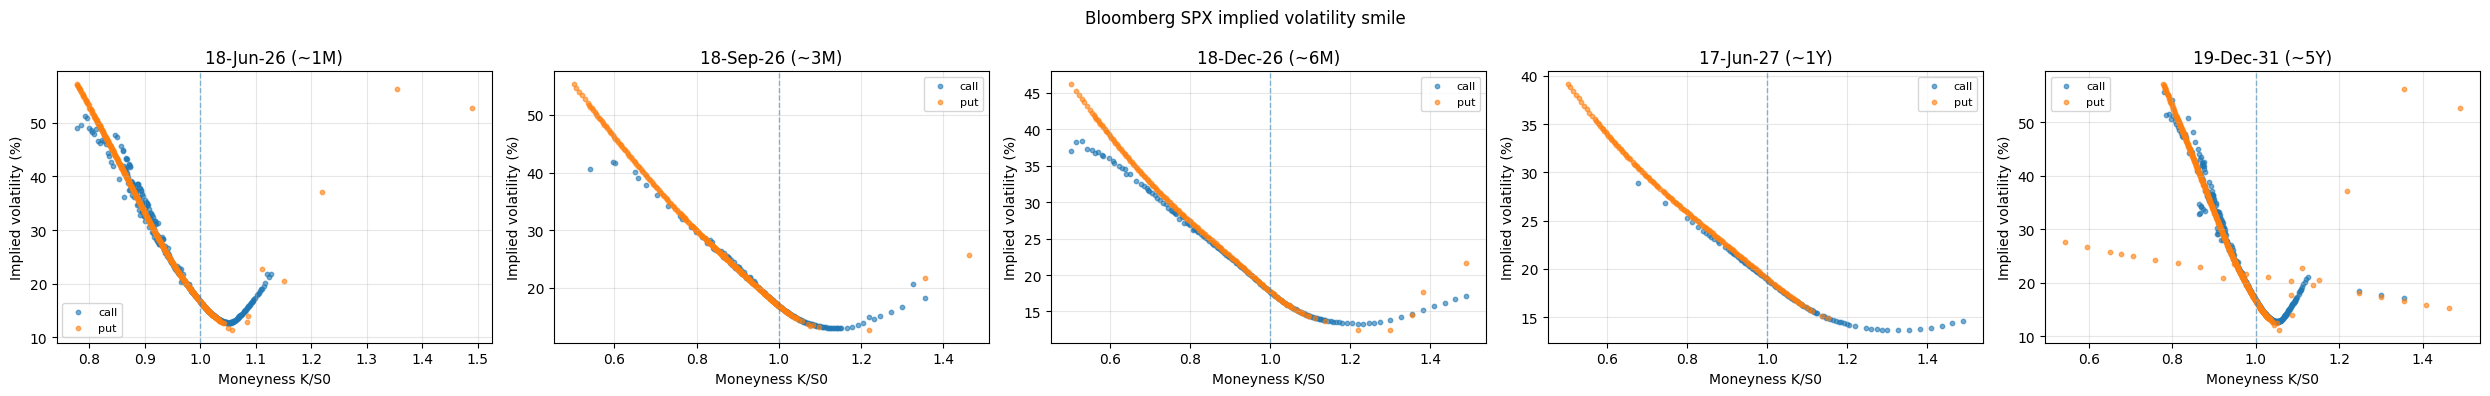

In [47]:
# 6 — DESCRIPTIVE STATISTICS AND SMILE PLOT

summary = options_final.groupby(['label', 'maturity', 'type']).agg(
    n=('strike', 'count'),
    strike_min=('strike', 'min'),
    strike_max=('strike', 'max'),
    iv_min=('impliedVolatility', 'min'),
    iv_max=('impliedVolatility', 'max'),
    oi_total=('openInterest', 'sum'),
).round(4)

display(summary)

maturities = options_final['maturity'].drop_duplicates().tolist()
fig, axes = plt.subplots(1, len(maturities), figsize=(5 * len(maturities), 4), squeeze=False)

for ax, mat in zip(axes[0], maturities):
    subset = options_final[options_final['maturity'] == mat]
    label = subset['label'].iloc[0]

    for opt_type in ['call', 'put']:
        tmp = subset[subset['type'] == opt_type]
        ax.scatter(tmp['moneyness'], tmp['impliedVolatility'] * 100, s=10, alpha=0.6, label=opt_type)

    ax.axvline(1.0, linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(f'{mat} ({label})')
    ax.set_xlabel('Moneyness K/S0')
    ax.set_ylabel('Implied volatility (%)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Bloomberg SPX implied volatility smile')
plt.tight_layout()
plt.savefig(DATA_DIR / 'bloom_smile.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 — Save outputs

In [11]:
# 7 — SAVE CSV AND METADATA

options_final.to_csv(OPTIONS_OUT, index=False)

metadata = {
    'spot_price': S0,
    'spot_date': SPOT_DATE,
    'n_options': int(len(options_final)),
    'n_calls': int((options_final['type'] == 'call').sum()),
    'n_puts': int((options_final['type'] == 'put').sum()),
    'maturities': options_final['maturity'].drop_duplicates().tolist(),
    'files_used': list(BLOOMBERG_FILES.keys()),
    'source': 'Bloomberg OMON',
    'filters': {
        'moneyness_min': MONEYNESS_MIN,
        'moneyness_max': MONEYNESS_MAX,
        'min_open_interest': MIN_OINT,
    }
}

with open(META_OUT, 'w') as f:
    json.dump(metadata, f, indent=4)

print('Saved:')
print(f'  {OPTIONS_OUT}')
print(f'  {META_OUT}')
print(f'  {DATA_DIR / "bloom_smile.png"}')

Saved:
  /Users/sca/Desktop/MS203/Masters Thesis/Script /data/spx_options_bloom.csv
  /Users/sca/Desktop/MS203/Masters Thesis/Script /data/metadata_bloom.json
  /Users/sca/Desktop/MS203/Masters Thesis/Script /data/bloom_smile.png


In [13]:
print(f'\nSummary:')
print(f'  Spot price : {S0:.2f} ({SPOT_DATE})')
print(f'  Options    : {len(options_final)} contracts')
print(f'  Calls      : {(options_final["type"]=="call").sum()}')
print(f'  Puts       : {(options_final["type"]=="put").sum()}')
print(f'  Maturities : {len(options_final["maturity"].unique())}')


Summary:
  Spot price : 7383.74 (2026-06-08)
  Options    : 2546 contracts
  Calls      : 1154
  Puts       : 1392
  Maturities : 5
